# Activation extraction: faces and places

Runs every image in `stimulus_subset/faces/` and `stimulus_subset/places/`
(900 each, spread across 9 source subfolders: `shared` +
`subject1`-`subject8`) through EVA-02-Base, capturing the output of all
12 transformer blocks - after each block's own final residual add, not
an intermediate step - giving a `(12, 768, 1024)` array per image
(12 blocks, 768-d embedding, 1,024 patch tokens; the CLS token is
dropped).

Faces and places are extracted and saved separately.

In [1]:
import glob
import os
import re
import time

import h5py
import numpy as np
import torch
import timm
from PIL import Image

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)


## 1. Load the model and register a hook on each block

In [2]:
model_name = "eva02_base_patch14_448.mim_in22k_ft_in22k_in1k"
model = timm.create_model(model_name, pretrained=True)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

n_blocks = len(model.blocks)
n_prefix = model.num_prefix_tokens
print(f"blocks: {n_blocks}, prefix tokens dropped: {n_prefix}")
print(f"device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""))

captured = {}

def make_hook(block_idx):
    def hook(module, inputs, output):
        captured[block_idx] = output.detach()
    return hook

for i, block in enumerate(model.blocks):
    block.register_forward_hook(make_hook(i))


blocks: 12, prefix tokens dropped: 1
device: cuda (NVIDIA GeForce RTX 3090)


## 2. Extraction function

Images are read from every source subfolder (`glob` with a wildcard for
the source directory) and processed as one batch per category. Each
image's activations are cast to float16 for storage (halves the file
size, negligible precision loss for this purpose).

In [3]:
def extract_category(category, out_path, batch_size=25):
    paths = sorted(glob.glob(f"stimulus_subset/{category}/*/*.png"))
    n_images = len(paths)
    nsd_ids = [int(re.search(r"nsd(\d+)", os.path.basename(p)).group(1)) for p in paths]
    sources = [os.path.basename(os.path.dirname(p)) for p in paths]
    images = [Image.open(p).convert("RGB") for p in paths]

    activations = np.empty((n_images, n_blocks, 768, 1024), dtype=np.float16)
    t_start = time.perf_counter()
    for start in range(0, n_images, batch_size):
        end = min(start + batch_size, n_images)
        batch = torch.stack([transform(img) for img in images[start:end]]).to(device)

        with torch.no_grad():
            model.forward_features(batch)

        for local_i in range(end - start):
            blocks_stacked = torch.stack(
                [captured[b][local_i, n_prefix:, :] for b in range(n_blocks)]
            )
            blocks_stacked = blocks_stacked.permute(0, 2, 1).cpu().numpy().astype(np.float16)
            activations[start + local_i] = blocks_stacked

    elapsed = time.perf_counter() - t_start
    print(f"{category}: {n_images} images, {elapsed:.1f}s ({elapsed / n_images:.3f}s/image)")
    print(f"  any NaNs: {np.isnan(activations).any()}, any Infs: {np.isinf(activations).any()}")

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with h5py.File(out_path, "w") as f:
        f.create_dataset(
            "activations", data=activations,
            chunks=(1, n_blocks, 768, 1024), compression="gzip", compression_opts=1,
        )
        f.create_dataset("nsd_id", data=np.array(nsd_ids))
        f.create_dataset("source", data=np.array(sources, dtype="S20"))
    print(f"  saved: {out_path}  ({os.path.getsize(out_path) / 1e9:.2f} GB)")
    return paths, nsd_ids


## 3. Run on both categories

In [4]:
face_paths, face_ids = extract_category("faces", "activations/faces/faces_activations.h5")


faces: 900 images, 61.9s (0.069s/image)


  any NaNs: False, any Infs: False


  saved: activations/faces/faces_activations.h5  (15.78 GB)


In [5]:
place_paths, place_ids = extract_category("places", "activations/places/places_activations.h5")


places: 900 images, 61.7s (0.069s/image)


  any NaNs: False, any Infs: False


  saved: activations/places/places_activations.h5  (15.77 GB)


## 4. Verify

In [6]:
for path in ["activations/faces/faces_activations.h5", "activations/places/places_activations.h5"]:
    with h5py.File(path, "r") as f:
        print(path, "->", f["activations"].shape, f["activations"].dtype, "| n_ids:", f["nsd_id"].shape)


activations/faces/faces_activations.h5 -> (900, 12, 768, 1024) float16 | n_ids: (900,)
activations/places/places_activations.h5 -> (900, 12, 768, 1024) float16 | n_ids: (900,)


## 5. Activations visualisation: 2 face & 2 place images

Each block's 1,024 patch-token vectors (768-d each) are collapsed to one
number per patch (L2 norm across the 768 channels) and reshaped back into
the original 32x32 patch grid - turning "768 numbers per patch" into a
brightness value per patch, viewable as an image.

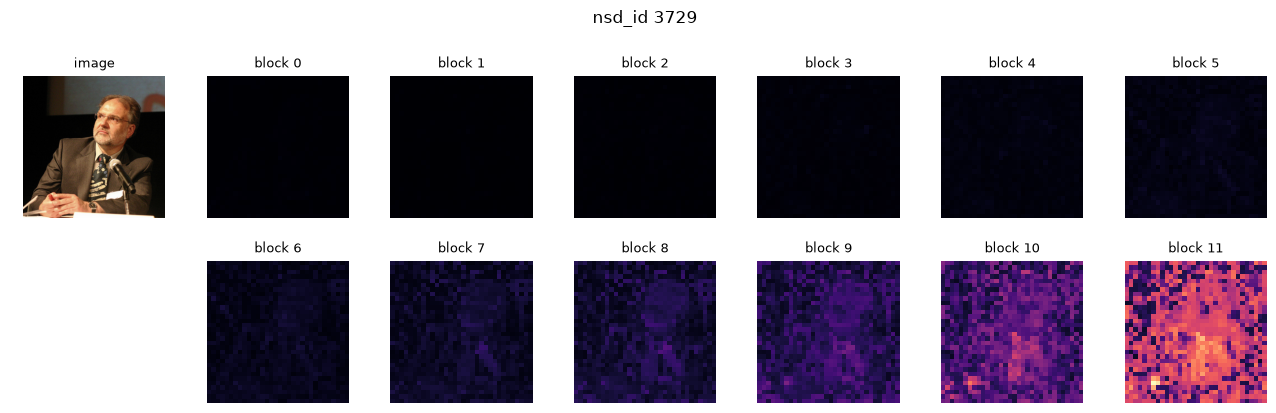

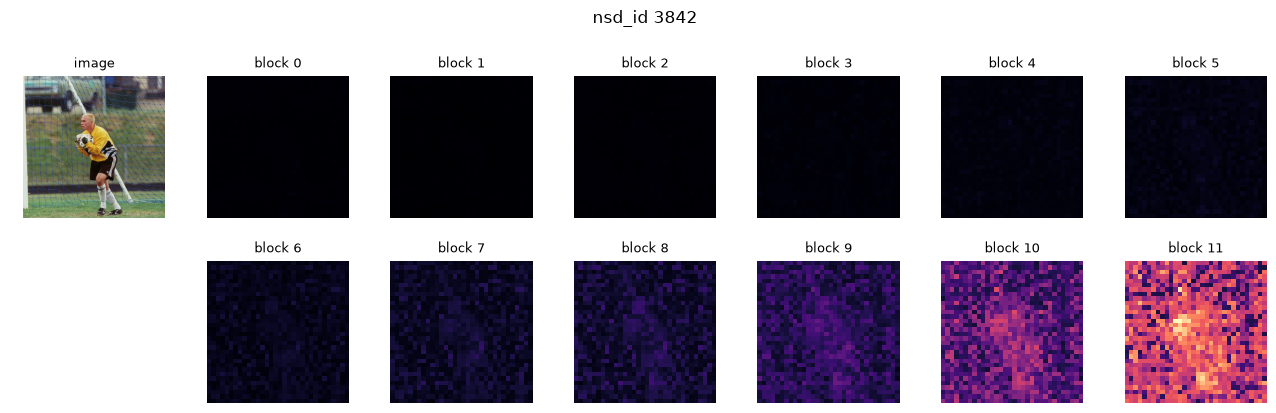

In [3]:
import matplotlib.pyplot as plt

def show_activations(image_path, nsd_id, activations_path, index):
    with h5py.File(activations_path, "r") as f:
        acts = f["activations"][index].astype(np.float32)  # (12, 768, 1024)

    # One norm map per block, all computed up front so a single vmin/vmax
    # can be shared across the 12 panels below - each block's own auto-scale
    # would otherwise hide how much activation magnitude actually grows with
    # depth. Shared only *within* this image; a different image gets its own
    # fresh vmin/vmax.
    norm_maps = np.linalg.norm(acts, axis=1).reshape(12, 32, 32)
    vmin = norm_maps.min()
    vmax = norm_maps.max()

    img = Image.open(image_path)
    fig, axes = plt.subplots(2, 7, figsize=(13, 4))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title("image", fontsize=9)
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")  # nothing goes under the image

    for b in range(12):
        row = 0 if b < 6 else 1
        col = (b % 6) + 1
        axes[row, col].imshow(norm_maps[b], cmap="magma", vmin=vmin, vmax=vmax)
        axes[row, col].set_title(f"block {b}", fontsize=9)
        axes[row, col].axis("off")

    fig.suptitle(f"nsd_id {nsd_id}", y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)  # small gap so row-2 titles don't sit on row-1 images
    plt.show()

for i in [0, 1]:
    show_activations(face_paths[i], face_ids[i], "activations/faces/faces_activations.h5", i)

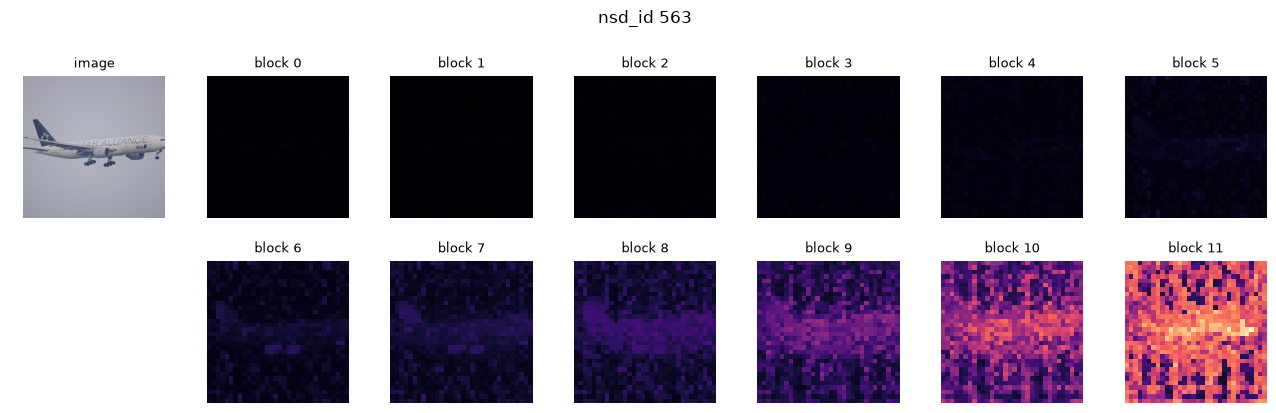

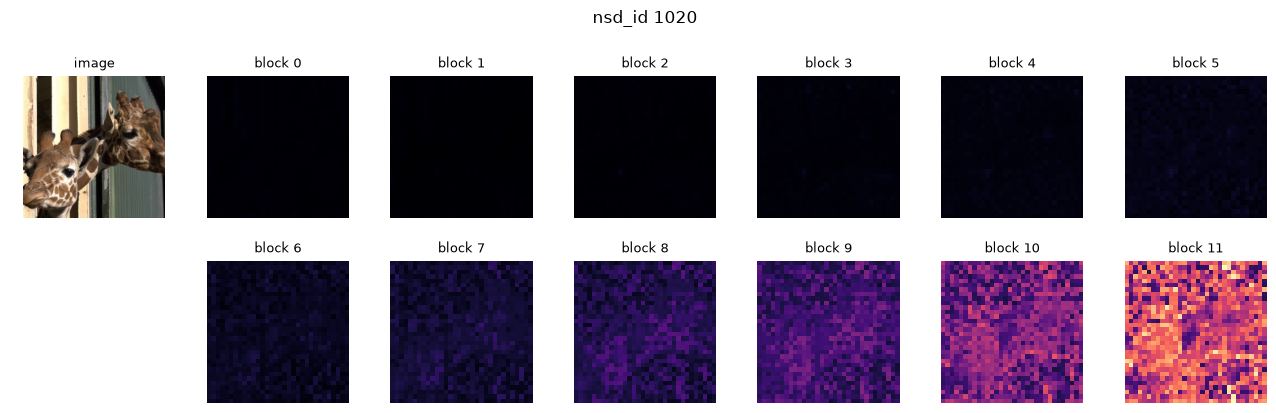

In [4]:
for nsd_id in [563, 1020]:
    i = place_ids.index(nsd_id)
    show_activations(place_paths[i], place_ids[i], "activations/places/places_activations.h5", i)

## 5b. Per-map scaling

Same as the two images above (nsd_id 3842 - face, nsd_id 563 - place), but
each block's auto-scales to its own min/max instead of sharing
one across the 12 panels.

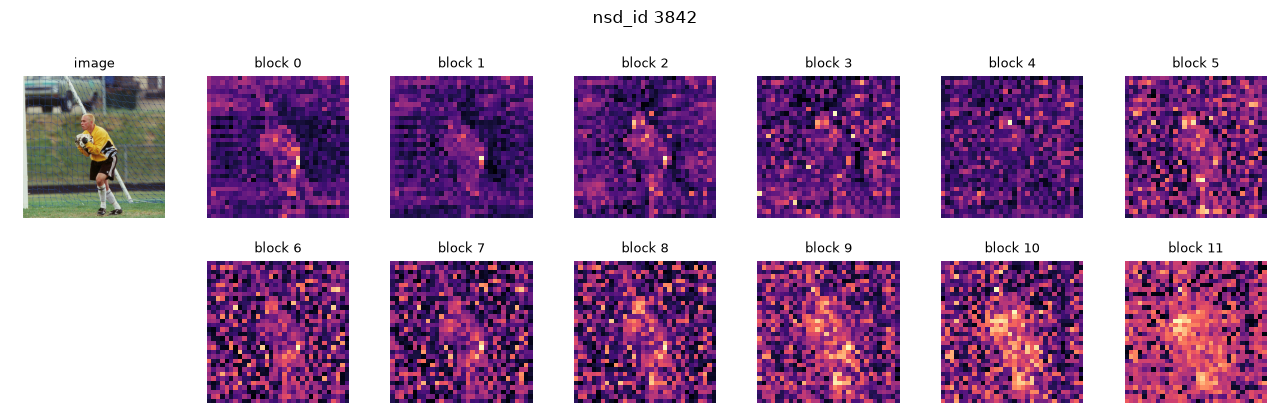

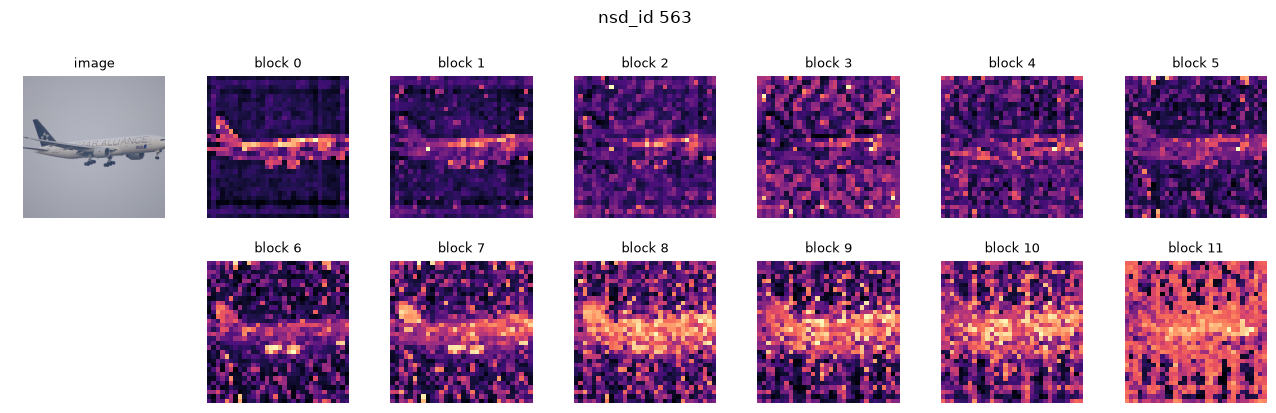

In [2]:
def show_activations_old(image_path, nsd_id, activations_path, index):
    with h5py.File(activations_path, "r") as f:
        acts = f["activations"][index].astype(np.float32)  # (12, 768, 1024)

    img = Image.open(image_path)
    fig, axes = plt.subplots(2, 7, figsize=(13, 4))

    axes[0, 0].imshow(img)
    axes[0, 0].set_title("image", fontsize=9)
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")

    for b in range(12):
        row = 0 if b < 6 else 1
        col = (b % 6) + 1
        norm_map = np.linalg.norm(acts[b], axis=0).reshape(32, 32)
        axes[row, col].imshow(norm_map, cmap="magma")  # no vmin/vmax: each panel auto-scales
        axes[row, col].set_title(f"block {b}", fontsize=9)
        axes[row, col].axis("off")

    fig.suptitle(f"nsd_id {nsd_id}", y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.show()

face_i = face_ids.index(3842)
show_activations_old(face_paths[face_i], face_ids[face_i], "activations/faces/faces_activations.h5", face_i)

place_i = place_ids.index(563)
show_activations_old(place_paths[place_i], place_ids[place_i], "activations/places/places_activations.h5", place_i)

## Summary

- All 12 EvaBlock outputs extracted (post-residual-add, CLS dropped) for
  every image in both the faces set (900 images) and places set (900
  images), keeping the two categories in separate files.
- `activations/faces/faces_activations.h5` and
  `activations/places/places_activations.h5`, each `(900, 12, 768, 1024)`
  float16, with `nsd_id` and `source` arrays alongside for tracing each
  row back to a specific image and subject/shared origin.